Goal: Understand the data: structure, csv content,data files content, show slices of random choice

Set and show Variables for local / HPC environments

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#=============functions ==========
def prepare_environment(hpc:bool):

    if hpc:
        data_path = 'MRI_2026_datasets/brain_age'
    else:
        #set local relative path to the data set
        data_path = '../../../../../../../mri_dataset/brain_age'

    data_path = os.path.abspath(data_path)
    print(f'Data path: {data_path}')
    os.chdir(data_path)

#============= main ==========
prepare_environment(hpc=False)


Read the csv files, show some information about the dataframes, and show some random slices of the dataframes

In [37]:
#============= Globals ==========
csvs = {'train':'student_train_metadata.csv',
        'test':'student_test_metadata.csv',
        'val':'student_val_metadata.csv'
        }
file_column_index = -1
dfs = {}
#=============functions ==========

def show_df_overview(name, df):
    print(f'\n==== {name} ====')
    print(f'Shape: {df.shape}')
    print('Columns:', list(df.columns))
    print('\nDtypes:')
    print(df.dtypes)
    print('\nMissing values per column:')
    print(df.isna().sum().sort_values(ascending=False))
    print('\nRandom sample rows:')
    print(df.sample(n=min(5, len(df)), random_state=42))

#============= main ==========
for key,value in csvs.items():
    dfs[key] = pd.read_csv(value)
    show_df_overview(key, dfs[key])
for key,value in dfs.items():
    assert value.columns.get_loc('filePath') == file_column_index or file_column_index == -1
    file_column_index = value.columns.get_loc('filePath') if file_column_index == -1 else file_column_index
print("file column index: ", file_column_index)



==== train ====
Shape: (4233, 4)
Columns: ['Subject', 'ProjName', 'Age', 'filePath']

Dtypes:
Subject         str
ProjName        str
Age         float64
filePath        str
dtype: object

Missing values per column:
Age         172
Subject       0
ProjName      0
filePath      0
dtype: int64

Random sample rows:
            Subject ProjName   Age  \
2016   Sub1038_Ses1      GSP  19.0   
1427      A00066827      NKI  26.0   
3658  CorrBNU_25955     Corr  19.5   
2812  SLIMsub-25637     SLIM  21.0   
2510  SLIMsub-25673     SLIM  20.0   

                                               filePath  
2016  /gpfs0/tamyr/projects/data/brain_age/npy/Sub10...  
1427  /gpfs0/tamyr/projects/data/brain_age/npy/A0006...  
3658  /gpfs0/tamyr/projects/data/brain_age/npy/CorrB...  
2812  /gpfs0/tamyr/projects/data/brain_age/npy/SLIMs...  
2510  /gpfs0/tamyr/projects/data/brain_age/npy/SLIMs...  

==== test ====
Shape: (243, 4)
Columns: ['Subject', 'ProjName', 'Age', 'filePath']

Dtypes:
Subject        

Shape: (90, 120, 99)
Dtype: float32
Minimum: 0.0
Maximum: 2.842836
Mean: 0.25534412
Complex: False


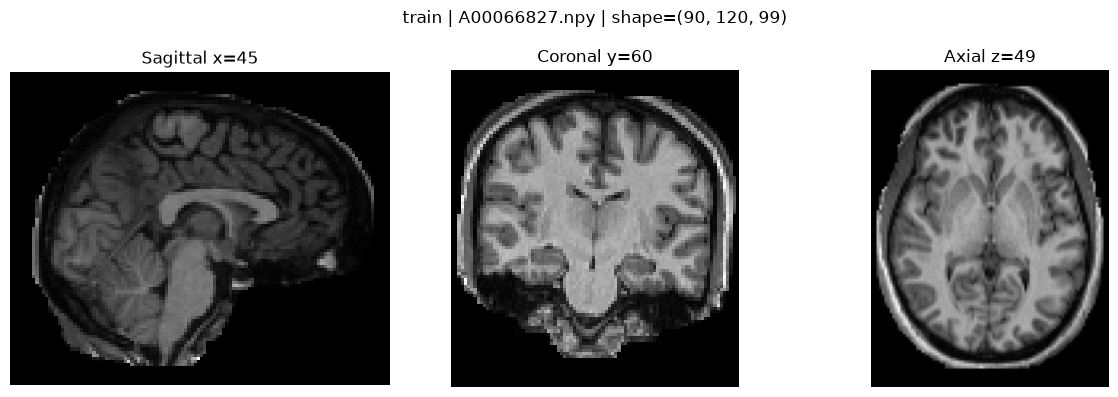

Shape: (90, 120, 99)
Dtype: float32
Minimum: 0.0
Maximum: 2.8163168
Mean: 0.24579571
Complex: False


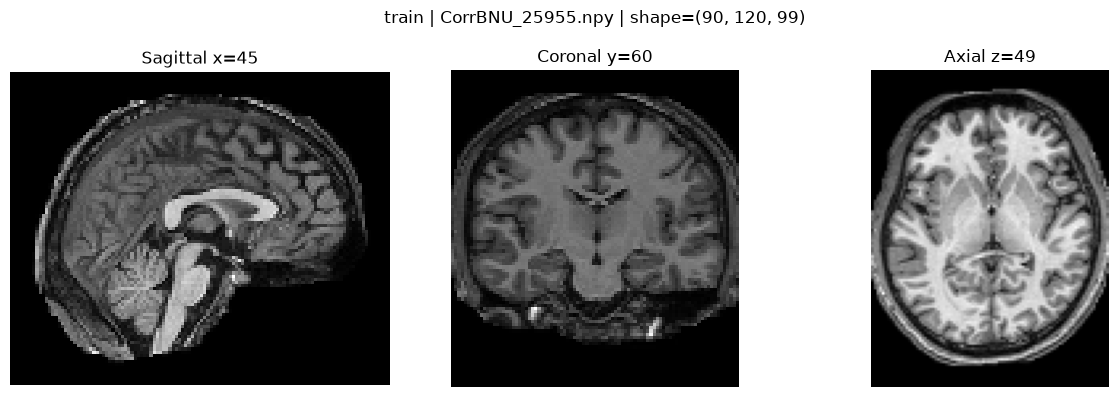

Shape: (90, 120, 99)
Dtype: float32
Minimum: 0.0
Maximum: 3.3523614
Mean: 0.22539708
Complex: False


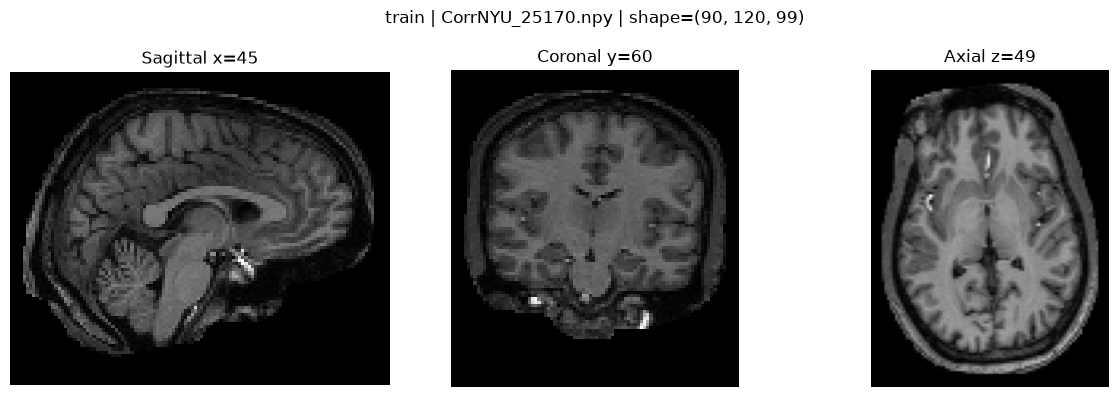

Shape: (90, 120, 99)
Dtype: float32
Minimum: 0.0
Maximum: 4.709748
Mean: 0.23635451
Complex: False


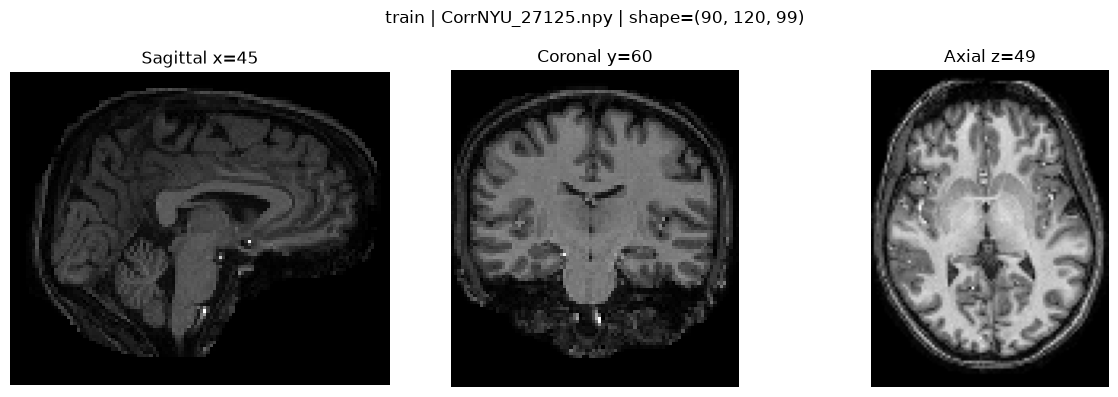

Shape: (90, 120, 99)
Dtype: float32
Minimum: 0.0
Maximum: 2.9156802
Mean: 0.3133939
Complex: False


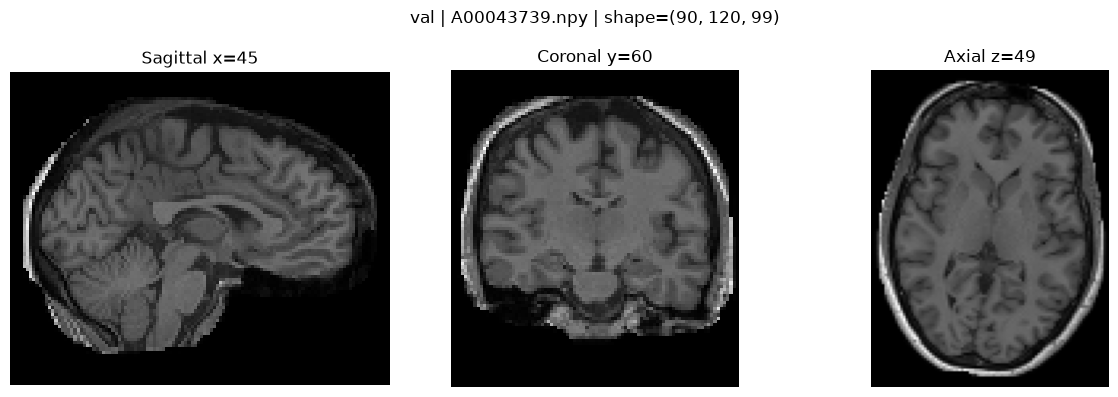

Shape: (90, 120, 99)
Dtype: float32
Minimum: 0.0
Maximum: 2.2310514
Mean: 0.26267043
Complex: False


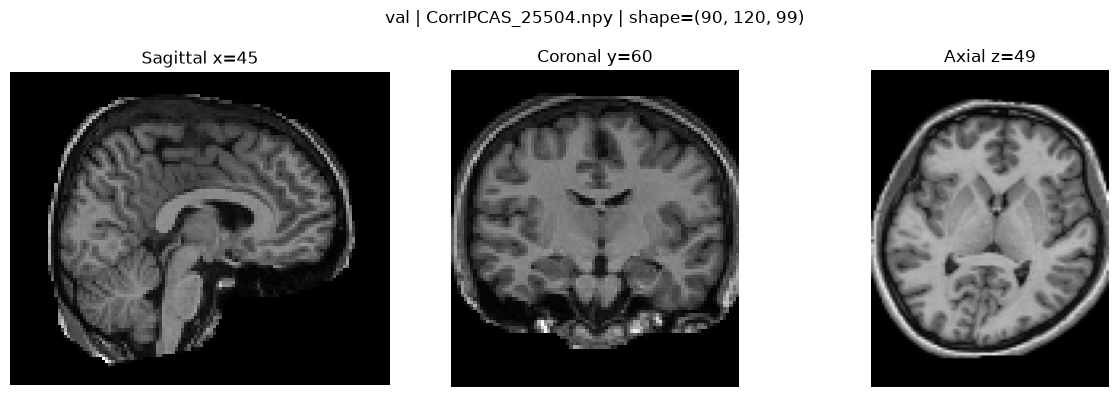

Shape: (90, 120, 99)
Dtype: float32
Minimum: 0.0
Maximum: 2.4545918
Mean: 0.2839526
Complex: False


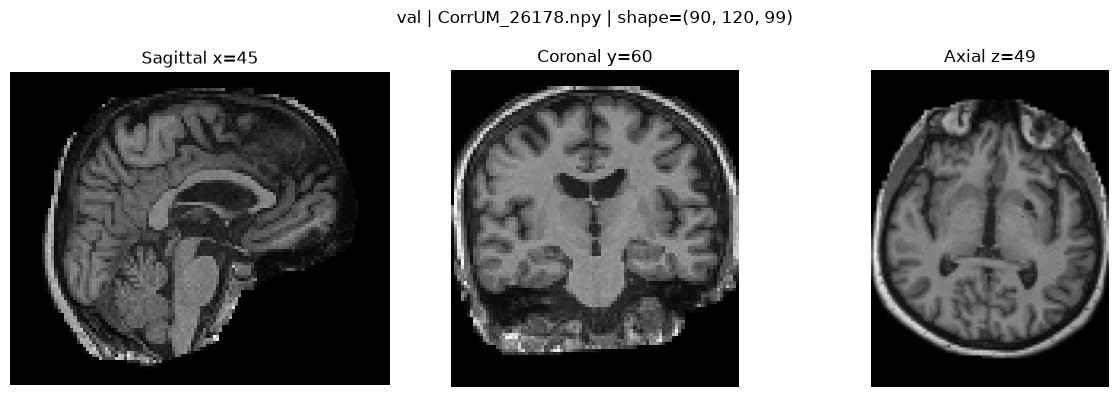

Shape: (90, 120, 99)
Dtype: float32
Minimum: 0.0
Maximum: 3.133046
Mean: 0.32125628
Complex: False


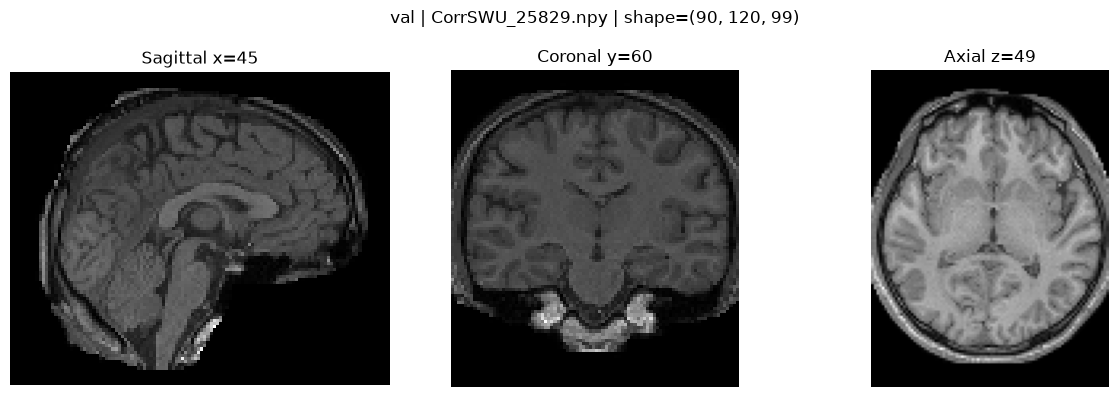

Shape: (90, 120, 99)
Dtype: float32
Minimum: 0.0
Maximum: 3.160968
Mean: 0.33589908
Complex: False


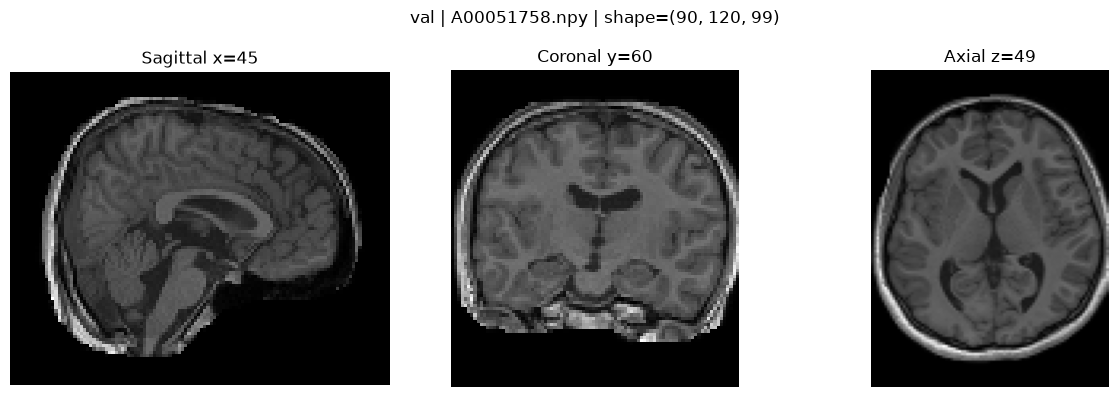

Shape: (90, 120, 99)
Dtype: float32
Minimum: 0.0
Maximum: 2.6977692
Mean: 0.31532228
Complex: False


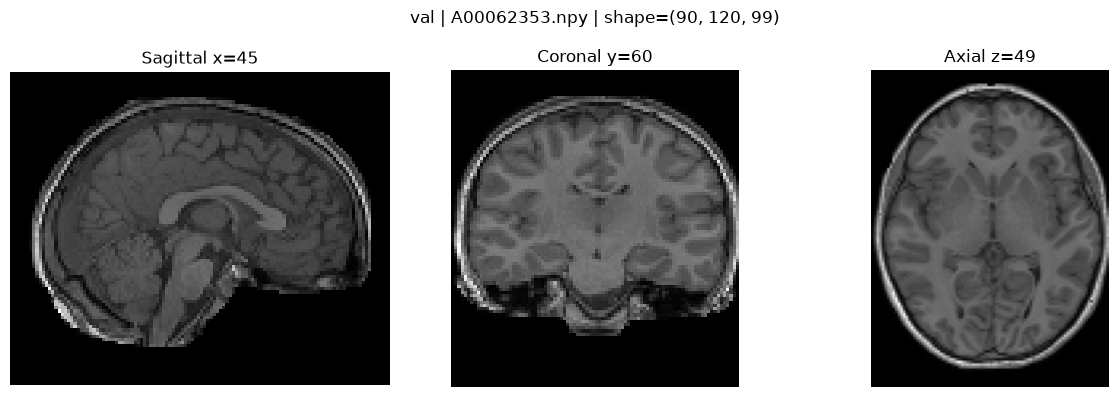

Shape: (90, 120, 99)
Dtype: float32
Minimum: 0.0
Maximum: 2.701461
Mean: 0.27582672
Complex: False


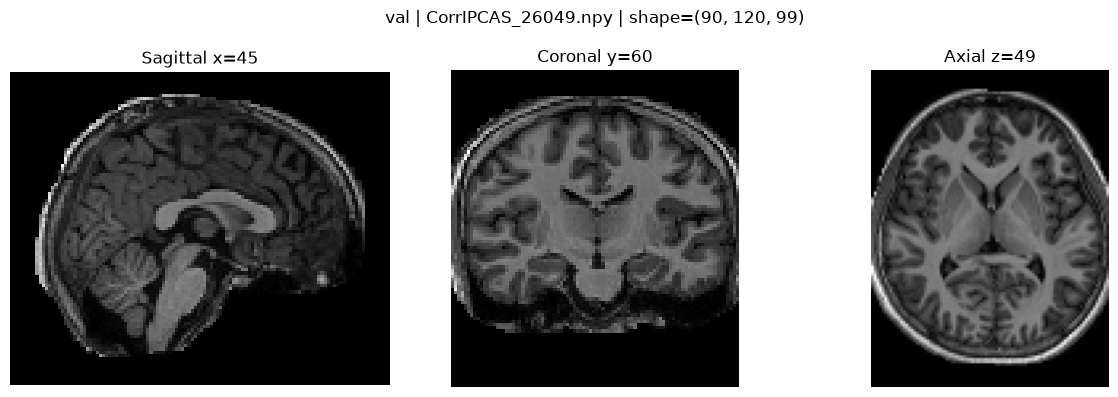

In [40]:
#=============functions ==========

def show_random_volume_slices(df, name, n_samples=2, seed=42):
    # print(f'\n==== {name} ====')
    sample_df = df.sample(n=min(n_samples, len(df)), random_state=seed)
    # print(f'Showing {len(sample_df)} random samples from {name}:')
    first = True
    for _, row in sample_df.iterrows():
        # print(f'\nRow: {row.to_dict()}')
        npy_path = os.path.join("selected_npy", os.path.basename(row['filePath']))
       # print(f'\nnpy_path: {npy_path}')

        if not os.path.exists(npy_path):
            continue

        vol = np.load(npy_path)
        if vol.ndim != 3:
            print(f"Skipping {npy_path}: expected 3D volume, got {vol.ndim}D")
            continue

        print("Shape:", vol.shape)
        print("Dtype:", vol.dtype)
        print("Minimum:", vol.min())
        print("Maximum:", vol.max())
        print("Mean:", vol.mean())
        print("Complex:", np.iscomplexobj(vol))

        cx, cy, cz = (s // 2 for s in vol.shape) #middle sections

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        fig.suptitle(f'{name} | {os.path.basename(npy_path)} | shape={vol.shape}')

        axes[0].imshow(np.rot90(vol[cx, :, :]), cmap='gray')
        axes[0].set_title(f'Sagittal x={cx}')
        axes[1].imshow(np.rot90(vol[:, cy, :]), cmap='gray')
        axes[1].set_title(f'Coronal y={cy}')
        axes[2].imshow(np.rot90(vol[:, :, cz]), cmap='gray')
        axes[2].set_title(f'Axial z={cz}')

        for ax in axes:
            ax.axis('off')

        plt.tight_layout()
        plt.show()

#============= main ==========
for key,value in dfs.items():
    show_random_volume_slices(value, key, n_samples=10, seed=42)
